In [1]:
# ============================================================
# 05_price_analysis.ipynb
# Price Analysis - Core drop-off visualisation
# ============================================================
# Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from db_connection import get_engine

engine = get_engine()
print("Connected.")

Connected.


In [2]:
# Load price segment data
query_segments = """
WITH price_segments AS (
    SELECT *,
        CASE
            WHEN price < 50                   THEN '1. Budget (<$50)'
            WHEN price >= 50  AND price < 200 THEN '2. Mid ($50-$199)'
            WHEN price >= 200 AND price < 500 THEN '3. Upper-mid ($200-$499)'
            WHEN price >= 500 AND price < 2000 THEN '4. Premium ($500-$1999)'
            WHEN price >= 2000                THEN '5. Enterprise ($2000+)'
        END AS price_segment
    FROM events_clean
)
SELECT
    price_segment,
    COUNT(DISTINCT CASE WHEN event_type = 'view'
          THEN user_id END)                          AS users_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'cart'
          THEN user_id END)                          AS users_carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase'
          THEN user_id END)                          AS users_purchased,
    ROUND(COALESCE(SUM(price) FILTER (WHERE event_type = 'purchase'), 0),
            2)                                       AS total_revenue,
    ROUND(AVG(price) FILTER
          (WHERE event_type = 'purchase'), 2)        AS avg_order_value,
    ROUND(
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END), 0), 2)              AS conversion_rate
FROM price_segments
GROUP BY price_segment
ORDER BY price_segment;
"""
seg_df = pd.read_sql(query_segments, engine)
seg_df['revenue_share'] = (
    seg_df['total_revenue'] / seg_df['total_revenue'].sum() * 100
).round(2)
print(seg_df)

              price_segment  users_viewed  users_carted  users_purchased  \
0          1. Budget (<$50)        202769         15474             9715   
1         2. Mid ($50-$199)        146132         11754             6624   
2  3. Upper-mid ($200-$499)         68055          9710             4823   
3   4. Premium ($500-$1999)         18492          1845              942   
4    5. Enterprise ($2000+)          1033            27                9   

   total_revenue  avg_order_value  conversion_rate  revenue_share  
0      383659.32            24.02             4.79           7.49  
1     1220356.13           103.56             4.53          23.81  
2     2561827.32           313.76             7.09          49.99  
3      932672.54           660.53             5.09          18.20  
4       26598.61          2955.40             0.87           0.52  


In [6]:
# Load price bucket data ($50 intervals)
query_buckets = """
WITH price_buckets AS (
    SELECT *,
        FLOOR(price / 50) * 50 AS price_bucket
    FROM events_clean
    WHERE price <= 2000
)
SELECT
    price_bucket                                              AS range_start,
    price_bucket + 50                                         AS range_end,
    CONCAT('$', price_bucket::int, '-$', 
           (price_bucket + 50)::int)                         AS price_range,
    COUNT(DISTINCT CASE WHEN event_type = 'view'
          THEN user_id END)                                  AS users_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase'
          THEN user_id END)                                  AS users_purchased,
     ROUND(COALESCE(SUM(price) FILTER (WHERE event_type = 'purchase'), 0),
            2)                                               AS total_revenue,
    ROUND(
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END), 0), 2)                      AS conversion_rate
FROM price_buckets
GROUP BY price_bucket
HAVING COUNT(DISTINCT CASE WHEN event_type = 'view'
             THEN user_id END) >= 500
ORDER BY range_start;
"""
bucket_df = pd.read_sql(query_buckets, engine)
print(f"Price buckets: {len(bucket_df)}")
print(bucket_df.head(10))

Price buckets: 20
   range_start  range_end price_range  users_viewed  users_purchased  \
0          0.0       50.0      $0-$50        202769             9715   
1         50.0      100.0    $50-$100         89267             3684   
2        100.0      150.0   $100-$150         42246             1852   
3        150.0      200.0   $150-$200         26708             1310   
4        200.0      250.0   $200-$250         22619             1571   
5        250.0      300.0   $250-$300         17953             1328   
6        300.0      350.0   $300-$350          9116              386   
7        350.0      400.0   $350-$400         14889              825   
8        400.0      450.0   $400-$450          7549              542   
9        450.0      500.0   $450-$500          9135              621   

   total_revenue  conversion_rate  
0      383659.32             4.79  
1      453396.89             4.13  
2      393039.95             4.38  
3      373919.29             4.90  
4      56

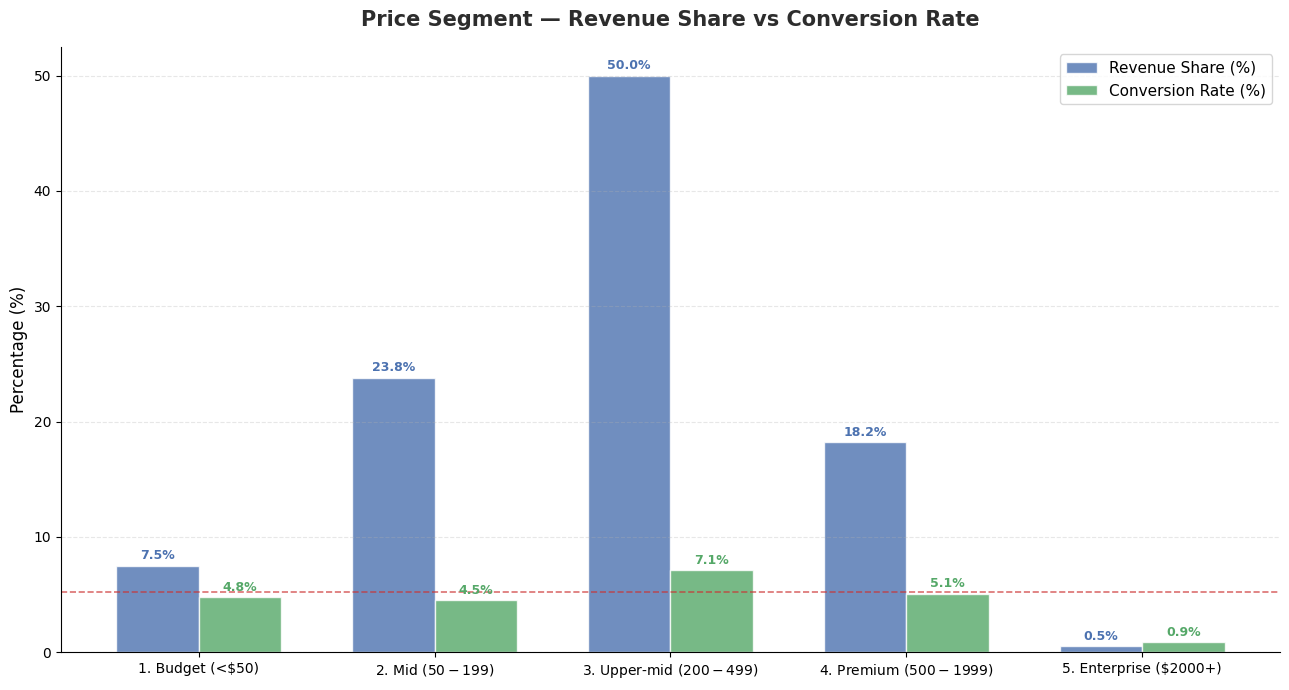

Saved.


In [7]:
# Price segment — conversion rate vs revenue share
fig, ax1 = plt.subplots(figsize=(13, 7))

x     = np.arange(len(seg_df))
width = 0.35

# Revenue share bars
bars1 = ax1.bar(
    x - width/2,
    seg_df['revenue_share'],
    width, color='#4C72B0', alpha=0.8,
    label='Revenue Share (%)', edgecolor='white'
)

# Conversion rate bars
bars2 = ax1.bar(
    x + width/2,
    seg_df['conversion_rate'],
    width, color='#55A868', alpha=0.8,
    label='Conversion Rate (%)', edgecolor='white'
)

# Value labels
for bar in bars1:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9,
        fontweight='bold', color='#4C72B0'
    )
for bar in bars2:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9,
        fontweight='bold', color='#55A868'
    )

ax1.set_xticks(x)
ax1.set_xticklabels(seg_df['price_segment'], fontsize=10)
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_title(
    'Price Segment — Revenue Share vs Conversion Rate',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)
ax1.axhline(y=5.24, color='#cc3333', linestyle='--',
            linewidth=1.2, alpha=0.7, label='Store avg (5.24%)')

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/05_segment_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

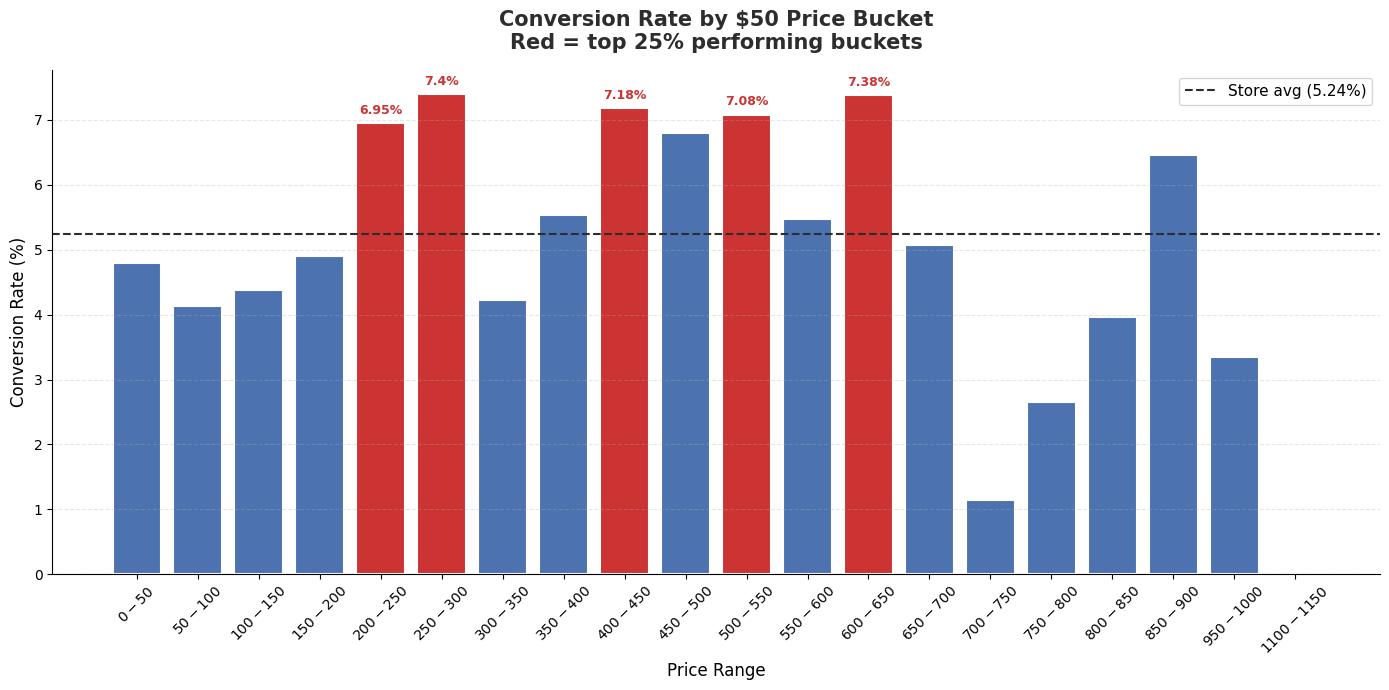

Saved.


In [9]:
# Price bucket conversion rate — find the sweet spot
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#cc3333' if v >= bucket_df['conversion_rate'].quantile(0.75)
          else '#4C72B0'
          for v in bucket_df['conversion_rate']]

bars = ax.bar(
    bucket_df['price_range'],
    bucket_df['conversion_rate'],
    color=colors, edgecolor='white', linewidth=1.5
)

# Store average line
ax.axhline(y=5.24, color='#2d2d2d', linestyle='--',
           linewidth=1.5, label='Store avg (5.24%)')

# Label top 5 bars only
top5_idx = bucket_df['conversion_rate'].nlargest(5).index
for idx in top5_idx:
    bar = bars[idx]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bucket_df.loc[idx, 'conversion_rate']}%",
        ha='center', va='bottom', fontsize=9,
        fontweight='bold', color='#cc3333'
    )

ax.set_title(
    'Conversion Rate by $50 Price Bucket\nRed = top 25% performing buckets',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Price Range', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/05_price_buckets.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

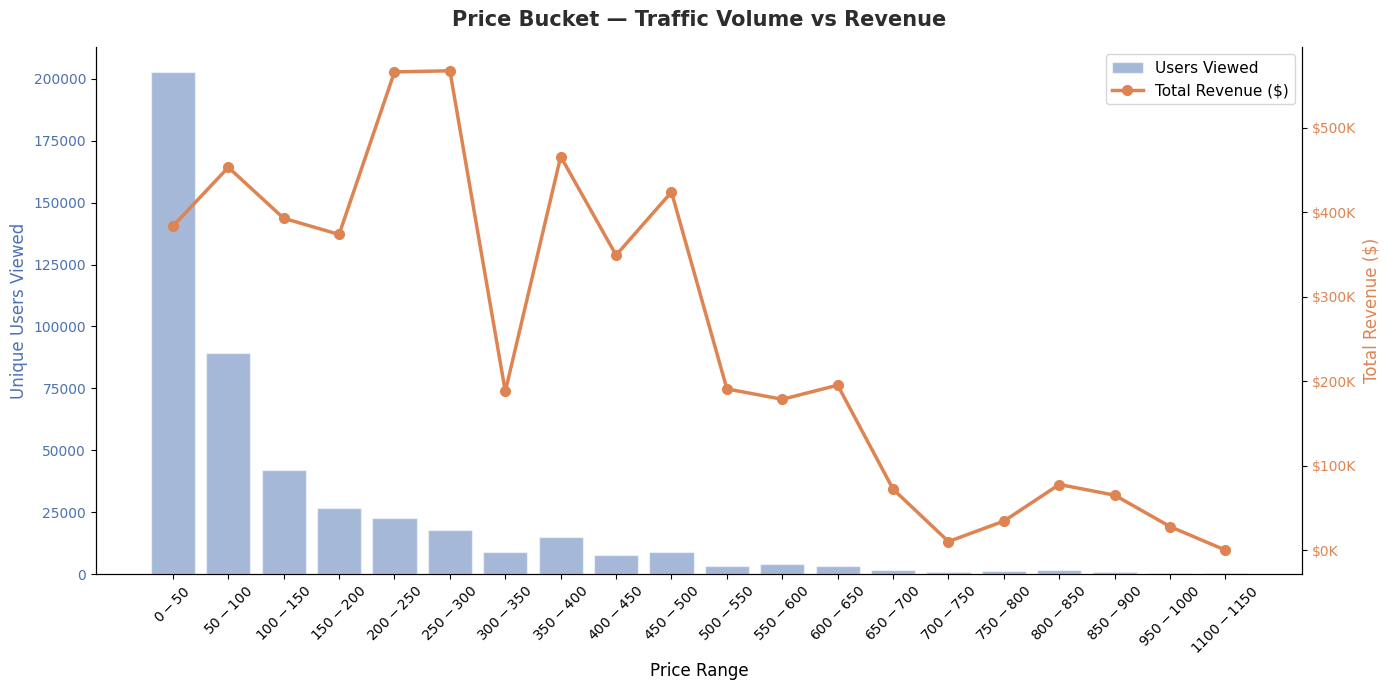

Saved.


In [10]:
# Revenue vs volume by price bucket
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(
    bucket_df['price_range'],
    bucket_df['users_viewed'],
    color='#4C72B0', alpha=0.5,
    label='Users Viewed', edgecolor='white'
)
ax1.set_ylabel('Unique Users Viewed', fontsize=12, color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    bucket_df['price_range'],
    bucket_df['total_revenue'],
    color='#DD8452', marker='o',
    linewidth=2.5, markersize=7,
    label='Total Revenue ($)'
)
ax2.set_ylabel('Total Revenue ($)', fontsize=12, color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

ax1.set_title(
    'Price Bucket — Traffic Volume vs Revenue',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax1.set_xlabel('Price Range', fontsize=12)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/05_price_volume_revenue.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

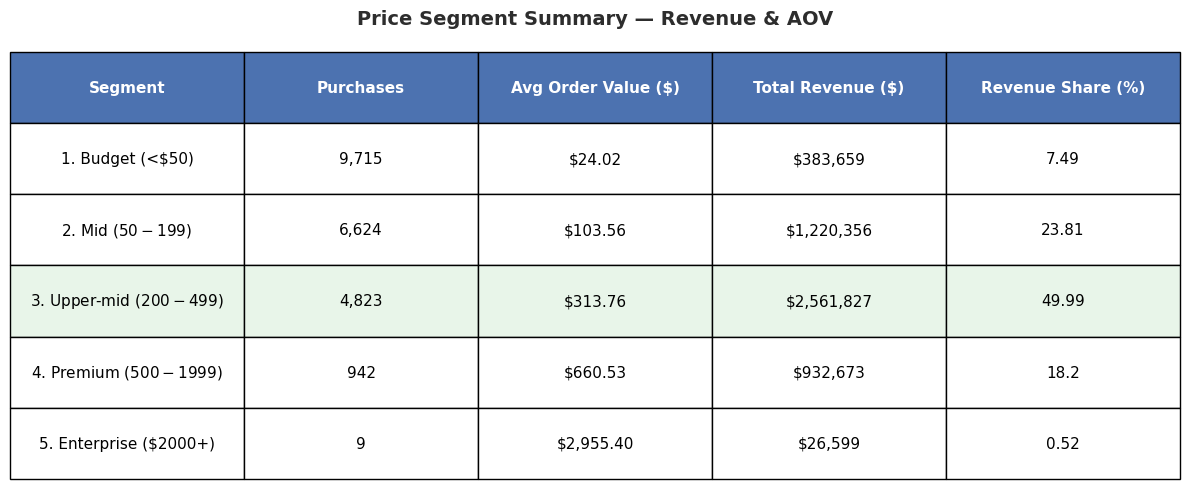

Saved.


In [11]:
# AOV and total revenue by segment — summary table visual
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

table_data = seg_df[[
    'price_segment', 'users_purchased',
    'avg_order_value', 'total_revenue', 'revenue_share'
]].copy()
table_data.columns = [
    'Segment', 'Purchases', 'Avg Order Value ($)',
    'Total Revenue ($)', 'Revenue Share (%)'
]
table_data['Total Revenue ($)'] = table_data['Total Revenue ($)'].apply(
    lambda x: f'${x:,.0f}'
)
table_data['Avg Order Value ($)'] = table_data['Avg Order Value ($)'].apply(
    lambda x: f'${x:,.2f}'
)
table_data['Purchases'] = table_data['Purchases'].apply(
    lambda x: f'{x:,}'
)

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Style header
for j in range(len(table_data.columns)):
    table[0, j].set_facecolor('#4C72B0')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight upper-mid row (index 3 = row 3)
for j in range(len(table_data.columns)):
    table[3, j].set_facecolor('#e8f5e9')

ax.set_title(
    'Price Segment Summary — Revenue & AOV',
    fontsize=14, fontweight='bold', pad=20, color='#2d2d2d'
)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/05_price_summary_table.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")